# Buffer ETFs — what does the comfort actually cost? 🛡️
### Defined-outcome funds promise a 15% airbag on the S&P 500. They kept the promise. Here's the bill — in plain words

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beat_the_dumb_mix%3F: Busted](https://img.shields.io/badge/Beat_the_dumb_mix%3F-Busted-8b949e?style=flat-square)

There is now a ~$50bn category of ETFs that sells you the stock market **with an airbag**: over each 12-month "outcome period" you're protected against the first 10–15% of losses, and in exchange your upside is **capped** (~10–12% a year) and you pay a fee about **ten times** an index fund's. The critics' line writes itself: *"you're paying a fat fee and giving away bull markets for insurance you could build yourself with an index fund and T-bills."*

So we audited both halves on the real tape: **did the airbag deploy** every time it was called, and **was the do-it-yourself version actually cheaper**?

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the decomposition and the robustness grids? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Data note.** BUFR (the flagship laddered buffer) + the four oldest Innovator Power Buffer funds, 2018–2026 — the category's *surviving flagships* (a mild tilt in the funds' favor, which we name). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from buffer_etf_cost import data, strategy as st

P_SERIES = ["PJAN", "PAPR", "PJUL", "POCT"]
HAVE_REAL = data.have_real()
if HAVE_REAL:
    ADJ, RAW = data.load_real(asof=data.AS_OF)
    M = data.monthly_returns(ADJ)
    SPY, BIL = M["SPY"], M["BIL"]
else:
    ADJ = RAW = M = SPY = BIL = None
print("real cache present:", HAVE_REAL)

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'fingerprint': 'e9356ec7ade8', 'fingerprint_raw': '2823f75e9835', 'n_periods': 25, 'n_down': 4, 'down_honored': 4, 'n_up': 21, 'n_capped': 16, 'mean_capped_ret': 11.71, 'mean_up_giveup': 9.98, 'pjan22': (-19.48, -5.29, -5.27), 'papr22': (-9.35, -0.88), 'periods': {'PJAN': [(16.16, 7.68), (27.04, 8.8), (-19.48, -5.29), (24.29, 18.18), (23.3, 13.45), (16.35, 11.29)], 'PAPR': [(53.77, 14.03), (13.96, 7.66), (-9.35, -0.88), (27.77, 14.25), (6.94, 6.16), (16.26, 11.61)], 'PJUL': [(5.24, 4.57), (38.82, 10.69), (-11.87, -0.78), (17.5, 16.47), (22.77, 13.53), (13.53, 12.87), (20.87, 11.31)], 'POCT': [(12.84, 8.48), (28.14, 11.06), (-16.77, -2.39), (19.68, 18.62), (34.22, 14.69), (16.11, 10.65)]}, 'vs_spy': {'BUFR': (5.26, 2.13, 70), 'PJAN': (7.75, 3.04, 89), 'PAPR': (8.27, 2.58, 86), 'PJUL': (6.34, 2.1, 94), 'POCT': (6.91, 2.4, 92)}, 'cohort_vs_spy': (7.24, 2.44, 86), 'lag_grid': (2.44, 2.44, 2.28), 'fair': {'BUFR': (0.59, 0.05, 0.06, 0.977), 'PJAN': (0.49, 0.51, 0.58, 0.949), 'PAPR': (0.4, 0.28, 0.31, 0.924), 'PJUL': (0.47, -0.33, -0.32, 0.942), 'POCT': (0.43, -0.94, -0.92, 0.936)}, 'cohort_fair': (0.44, -0.19, -0.24, 0.965), 'winners': '2/5', 'perf': {'BUFR': (10.49, 9.56, -13.28, 0.79), 'SPY': (15.53, 15.68, -23.93, 0.82), 'BIL': (2.95, 0.63, -0.13, None), 'mix 0.59': (10.57, 9.33, -14.37, 0.82), 'mix 0.70': (11.89, 10.99, -16.93, 0.82)}, 'dec_bufr': (0.05, 0.95, 0.83, -1.74), 'dec_cohort': (-0.19, 0.79, 0.62, -1.6), 'wgrid': [(0.45, -1.79, -2.34), (0.55, -0.51, -0.78), (0.65, 0.77, 0.87), (0.7, 1.41, 1.31)], 'cost_grid': [(2, 0.05), (5, 0.04), (10, 0.03)], 'syn_gap': [(0.0, -0.06, -0.3), (2.0, 1.94, 9.99)], 'syn_delivery': (14, 14, 9.19, 9.21)}


real cache present: True


## The answer first

| Question | Answer |
|---|---|
| Did the buffer actually work? | **Yes, every time.** In all **4** down years on the tape the funds delivered the promised floor — in 2022 the S&P fell **19.5%** and the January fund lost only **5.3%**, within 2 bps of its contract. |
| Did the cap really eat your upside? | **Yes, hard.** In **16 of 21** up years the cap bound: the funds plateaued near **+12%** while the S&P's up years averaged about **+22%**. |
| So they're a rip-off? | **No — that's the twist.** The 5–8%/yr they trail the market is just *owning less market*. Against an honest same-risk mix of index fund + T-bills, the buffer funds came out **dead even** (and 2 of 5 even nosed ahead). |
| Could you have built it cheaper? | **Not on this tape.** The fee and lost dividends (~1.8%/yr) were real — but the option structure **earned them back**, mostly by cushioning 2022. The comfort was fairly priced. |

> The product is mechanically honest **and** the critique is half-wrong: you pay for the airbag, the airbag deploys, and the DIY alternative saved you nothing.

## 1 · The claim

> *"Buffer ETFs deliver exactly the buffer they promise — and charge you the upside cap plus a fat fee for insurance you could build cheaper."*

That's the standard advisor-press critique (Morningstar has run versions of it; academics like Israelov call it *the hidden cost of buffer funds*). Note it has **two halves**: the funds are *honest* (they deliver the terms) but *overpriced* (a plain index + T-bill mix should beat them). Both halves are testable.

## 2 · So what?

Tens of billions of retirement dollars moved into these wrappers after 2020. If the critique is right, all of that is paying ~0.8–0.95%/yr for something a two-fund portfolio replicates for ~0.1%. If it's wrong, the wrapper is a fair deal for people who genuinely cannot sit through a −20% year without selling — which is the whole behavioral point of the product.

## 3 · How would we even know?

Three measurements on the 2018–2026 tape:

1. **Delivery.** For each completed 12-month outcome period, pair the fund's return with SPY's **price** return (that's what the contract is written on) and check the floor and the cap against the stated terms.
2. **The cost.** How much did each fund trail SPY's total return, and is that gap statistically real?
3. **The fair race.** Each fund vs the *dumb mix it replaces* — the same equity exposure built from SPY + T-bills (BIL), rebalanced monthly with trading costs charged.

## 4 · The teardown — let's actually look

**First, delivery.** Every completed outcome period, promise vs reality:

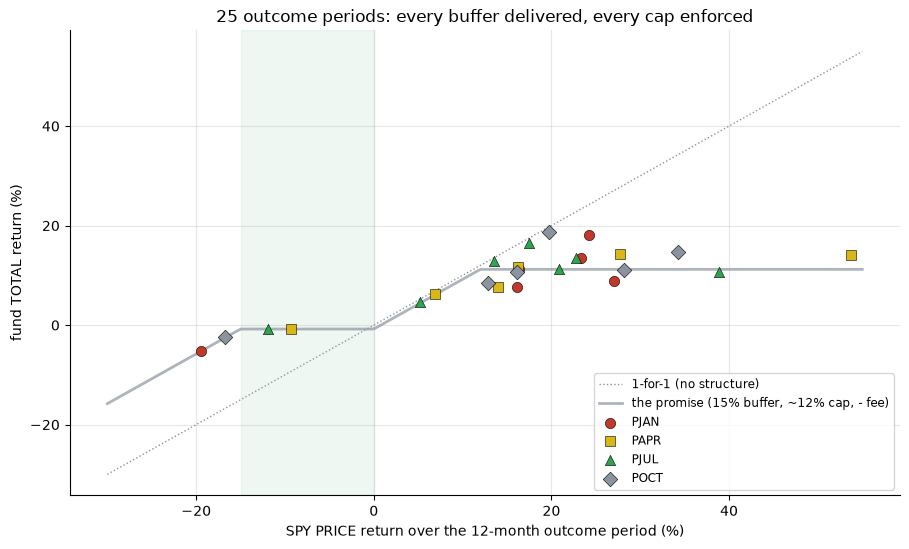

25 completed periods, 4 down periods - buffer honored in all of them


In [2]:
# every completed outcome period: SPY PRICE return (the stated reference) vs fund TOTAL return
if HAVE_REAL:
    pairs = {tk: [(r["spy_price_ret_pct"], r["fund_ret_pct"]) for _, r in
                  st.outcome_periods(ADJ[tk], RAW["SPY"], data.FUNDS[tk]["reset_month"]).iterrows()]
             for tk in P_SERIES}
else:
    pairs = R["periods"]
fig, ax = plt.subplots(figsize=(9.2, 5.6))
xs = np.linspace(-30, 55, 300)
ax.plot(xs, xs, ls=":", c=GREY, lw=1, label="1-for-1 (no structure)")
promise = np.where(xs >= 0, np.minimum(xs, 12.0), np.where(xs >= -15, 0.0, xs + 15.0)) - 0.79
ax.plot(xs, promise, c=GREY, lw=2, alpha=.7, label="the promise (15% buffer, ~12% cap, - fee)")
ax.axvspan(-15, 0, color=GREEN, alpha=.08)
marks = dict(PJAN="o", PAPR="s", PJUL="^", POCT="D")
for tk, pts in pairs.items():
    px, py = zip(*pts)
    ax.scatter(px, py, marker=marks[tk], s=55, color=(RED if tk == "PJAN" else GREEN if tk == "PJUL" else AMBER if tk == "PAPR" else GREY),
               edgecolor="k", linewidth=.4, label=tk, zorder=3)
ax.set_xlabel("SPY PRICE return over the 12-month outcome period (%)")
ax.set_ylabel("fund TOTAL return (%)")
ax.set_title("25 outcome periods: every buffer delivered, every cap enforced")
ax.legend(fontsize=8.5); plt.tight_layout(); plt.show()
n_down = sum(1 for pts in pairs.values() for x, _ in pts if x < 0)
print(f"{sum(len(v) for v in pairs.values())} completed periods, {n_down} down periods - buffer honored in all of them")


The dots trace the promised payoff shape almost perfectly: flat at ~0 inside the buffer zone (green band), floor honored in **4/4** down periods (PJAN 2022: SPY price **-19.48%** → fund **-5.29%**, contract floor **-5.27%**), and a hard ceiling near **+12%** — the cap bound in **16/21** up periods, costing about **10 points per up year**. The product does exactly what the label says: full airbag, hard ceiling.

**Now the bill.** How much market did the comfort cost — and does it survive the fair comparison? Left: each fund vs SPY. Right: each fund vs its honest same-risk SPY/BIL mix.

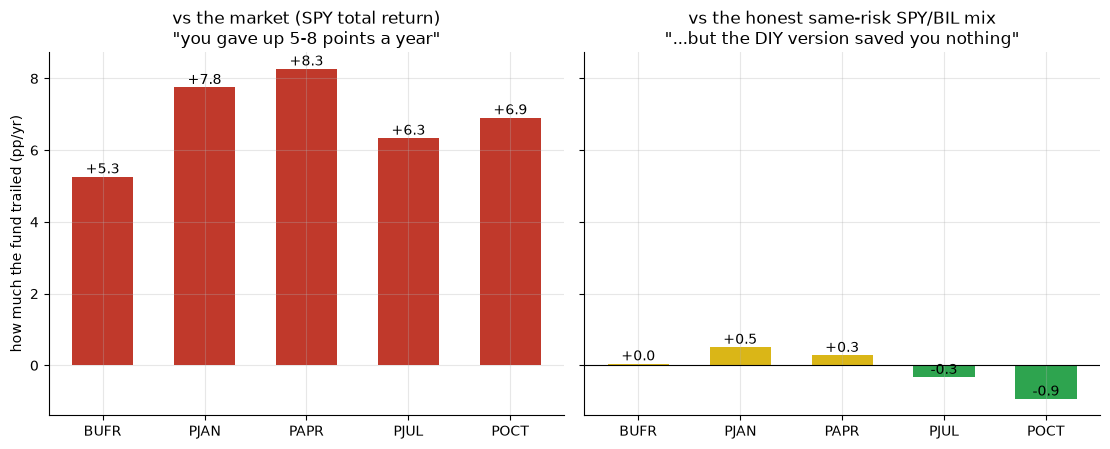

vs SPY (pp/yr): [5.3, 7.8, 8.3, 6.3, 6.9]  | vs beta-matched mix: [0.0, 0.5, 0.3, -0.3, -0.9]


In [3]:
funds = list(R['vs_spy'])
if HAVE_REAL:
    vs_spy, fair = [], []
    for tk in funds:
        f = M[tk].dropna()
        vs_spy.append(st.gap_stats(f, SPY.loc[f.index])['gap_pp_yr'])
        b = st.beta_vs(f, SPY, BIL)
        fair.append(st.gap_stats(f, st.mix_returns(SPY.loc[f.index], BIL.loc[f.index], b))['gap_pp_yr'])
else:
    vs_spy = [R['vs_spy'][tk][0] for tk in funds]
    fair = [R['fair'][tk][1] for tk in funds]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.6), sharey=True)
a1.bar(funds, vs_spy, color=RED, width=.6)
for i, v in enumerate(vs_spy): a1.annotate(f'{v:+.1f}', (i, v), ha='center', va='bottom')
a1.set_title('vs the market (SPY total return)\n"you gave up 5-8 points a year"')
a1.set_ylabel('how much the fund trailed (pp/yr)')
a2.bar(funds, fair, color=[GREEN if v <= 0 else AMBER for v in fair], width=.6)
for i, v in enumerate(fair): a2.annotate(f'{v:+.1f}', (i, v), ha='center', va='bottom')
a2.axhline(0, c='k', lw=.8)
a2.set_title('vs the honest same-risk SPY/BIL mix\n"...but the DIY version saved you nothing"')
plt.tight_layout(); plt.show()
print('vs SPY (pp/yr):', [round(v, 1) for v in vs_spy], ' | vs beta-matched mix:', [round(v, 1) for v in fair])

The left panel is the critics' chart: every fund trailed the market by **5–8 points a year** — and the quants notebook shows that's statistically solid, not luck. The right panel is the punchline: against the **same-risk** dumb mix the gaps shrink to **fractions of a point in either direction** (2 of 5 funds actually ahead). The "cost of comfort" was really just *owning about half as much stock market* — which is what you asked for when you bought an airbag.

**Same story in risk-and-return terms** (BUFR's window, Sep 2020 → Jun 2026):

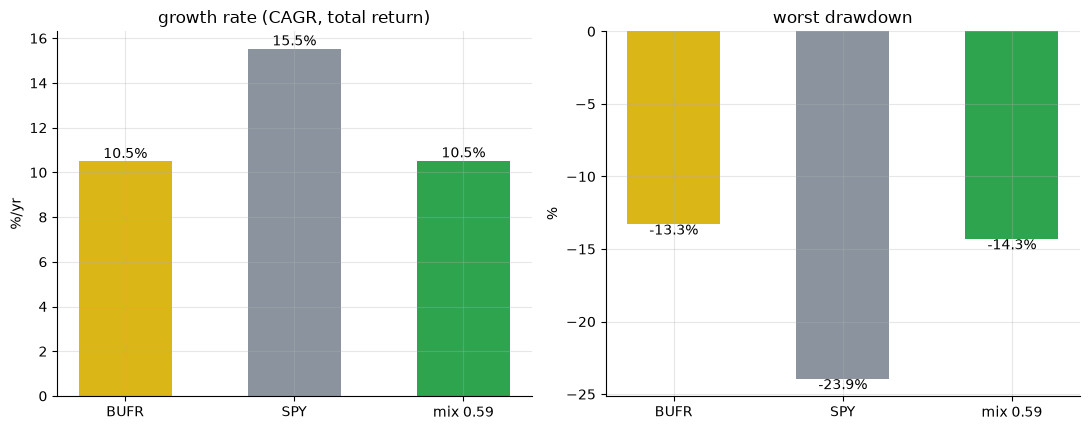

CAGR: [10.5, 15.5, 10.5]  maxDD: [-13.3, -23.9, -14.3]


In [4]:
labels = ['BUFR', 'SPY', 'mix 0.59']
if HAVE_REAL:
    f = M['BUFR'].dropna(); win = f.index
    legs = {'BUFR': f, 'SPY': SPY.loc[win], 'mix 0.59': st.mix_returns(SPY.loc[win], BIL.loc[win], 0.59)}
    stats = {k: st.perf_stats(v, BIL.loc[win]) for k, v in legs.items()}
    cagr = [stats[k]['cagr_pct'] for k in labels]; dd = [stats[k]['maxdd_pct'] for k in labels]
else:
    cagr = [R['perf'][k][0] for k in labels]; dd = [R['perf'][k][2] for k in labels]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.4))
a1.bar(labels, cagr, color=[AMBER, GREY, GREEN], width=.55)
for i, v in enumerate(cagr): a1.annotate(f'{v:.1f}%', (i, v), ha='center', va='bottom')
a1.set_title('growth rate (CAGR, total return)'); a1.set_ylabel('%/yr')
a2.bar(labels, dd, color=[AMBER, GREY, GREEN], width=.55)
for i, v in enumerate(dd): a2.annotate(f'{v:.1f}%', (i, v), ha='center', va='top')
a2.set_title('worst drawdown'); a2.set_ylabel('%')
plt.tight_layout(); plt.show()
print('CAGR:', [round(v,1) for v in cagr], ' maxDD:', [round(v,1) for v in dd])

BUFR and its same-risk mix are **near-twins**: 10.5% vs 10.6% a year, worst drawdowns -13.3% vs -14.4% (the buffer's was actually *shallower* — that's what the fee bought). SPY grew faster (15.5%) but fell almost twice as far in 2022. Pick your poison; nobody got cheated.

## 5 · The verdict

- **Signal — Real.** The cost of comfort is genuine and statistically solid: every fund trailed SPY by **5–8 points a year**, and the cap bound in **16 of 21** up years.
- **Tradability — Mirage.** But you can't *harvest* that gap, because it's just lower equity exposure: the honest same-risk SPY/BIL mix **tied** the buffer funds (±1 point, well within noise). "Build it cheaper yourself" saved exactly nothing on this tape.
- **Beat the dumb mix? — Busted.** No fund beat its mix by a statistically real margin — and none lost to it either. The comfort was **fairly priced ex post**.

## 6 · Going further 🚪

- **The behavioral defense is the real product.** If the airbag stops one panic-sell at the bottom of a −20% year, it paid for a decade of fees. That's not in our arithmetic — and it's the strongest honest case for these funds.
- **This tape had one bear.** 2022 fell just beyond the 15% buffer — near-ideal conditions for the structure. A decade with no bear (caps bind every year, insurance never pays) would tilt the fair race toward the mix; a −40% crash would too (the buffer stops at 15). The tie is sample-specific; the *delivery* is contractual.
- **Watch the entry date.** Buy mid-period and the remaining cap/buffer can be very different from the label — the laddered BUFR exists precisely to smooth that away.

*Think a two-fund mix beats the wrapper over the** next **decade? The engine reruns in one line as the outcome periods complete — check back after the next bear.*